<a href="https://colab.research.google.com/github/karanamsubbarao/llm-course/blob/main/LLM_Assignment_Notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


**Section 0 : Tokenization Trade-offs (8 points)**

Goal: Understand the trade-offs between different tokenization strategies.
Tasks

Implement two tokenizers from scratch:

*   Character-level: Vocabulary = all unique characters (case-sensitive)
*   Whitespace: Split on whitespace, with punctuation as separate tokens
*   Compare with Tiktoken (GPT-2 BPE):

*   Tokenize this book (url : https://www.gutenberg.org/cache/epub/11/pg11.txt) with all three tokenizers
*   Compute these three metrics for each tokenizer:
*   Compression ratio : total characters ÷ total tokens emitted for the corpus.
*   Measures how compactly the tokenizer encodes this text / corpus.
*   Average token length : the mean character length of the unique tokens in the vocabulary (each token type counted once, unweighted)
*   Vocabulary size : the number of distinct tokens (the unique characters/words in the text for the char-level/whitespace tokenizers; the fixed BPE vocabulary for Tiktoken).

Deliverables
•
Code for both tokenizers with encode() and decode() methods
•
Bar chart: Compare the three tokenizers on vocabulary size and compression ratio
•
Analysis (~ 100 words): Explain the trade-off between vocabulary size and sequence length. Why might a small vocabulary (char-level) lead to worse model performance despite preserving all information?


# New Section

In [ ]:
## Parse the URL and download the contents of https://www.gutenberg.org/cache/epub/11/pg11.txt
import os
import requests
import matplotlib.pyplot as plt

#Download the contents of pg11.txt to a file
if not os.path.exists("pg11-contents.txt"):
    url = ("https://www.gutenberg.org/cache/epub/11/pg11.txt")
    file_path = "pg11-contents.txt"

    response = requests.get(url, timeout=30)
    response.raise_for_status()
    with open(file_path, "wb") as f:
        f.write(response.content)
raw_text = open("pg11-contents.txt", "r", encoding="utf-8").read()

In [ ]:
import os
import requests

class CharacterTokenizer:
  def __init__(self,vocab):
    self.unk_token = "<UNK>"
    self.vocab = {v:k for k, v in enumerate(vocab)}
    self.vocab[self.unk_token] = len(vocab)
    self.inv_vocab = {v: k for k, v in self.vocab.items()}

  def encode(self, text) :
    unk_id = self.vocab[self.unk_token]
    return [self.vocab.get(c,unk_id) for c in list(text)]

  def decode(self, ids):
     return ''.join(self.inv_vocab[i] for i in ids)

  def calculate_compression_ratio(self,text,token_ids):
      num_chars = len(text)
      num_tokens = len(token_ids)
      ratio = num_tokens / num_chars
      return ratio

  def calculate_compression_ratio(self,text,token_ids):
      num_chars = len(text)
      num_tokens = len(token_ids)
      ratio = num_tokens / num_chars
      return ratio

  def average_token_length(self,text,token_ids) :
      num_tokens = len(token_ids)
      mean_length = len(text)/num_tokens
      return mean_length

  def vocab_size(self):
     return len(self.vocab)


# ==========================================
# Example Usage
# ==========================================
if __name__ == "__main__":
    vocab = list("abcdefghijklmnopqrstuvwxyzABCDEFGHIJKLMNOPQRSTUVWXYZ!.")  # Vocabulary of all unique characters
    tokenizer = CharacterTokenizer(vocab)
    #Download the contents of pg11.txt to a file
    raw_text = open("pg11-contents.txt", "r", encoding="utf-8").read()
    #tokenizer.build_vocabulary(sample_text)
    token_ids = tokenizer.encode(raw_text)
    #print("Encoded Tokens:", token_ids)
    decoded_text = tokenizer.decode(token_ids)
    #print("decoded_text:", decoded_text)
    print("Compression Ratio", tokenizer.calculate_compression_ratio(raw_text,token_ids))
    print("Average token length", tokenizer.calculate_compression_ratio(raw_text,token_ids))
    print("vocabulary_size", tokenizer.vocab_size())

Compression Ratio 1.0
Average token length 1.0
vocabulary_size 55


 **White Space Tokenizer**

In [ ]:
class WhiteSpaceTokenizer :
    def __init__(self,unk_token="<UNK>"):
      self.unk_token = unk_token
      self.vocab = {unk_token: 0}
      self.inverse_vocab = {0: unk_token}

    # Build vocabulary dynamically
    def build_vocabulary(self, text):
       for token in text.split():
          if token not in self.vocab:
              new_id = len(self.vocab)
              self.vocab[token] = new_id
              self.inverse_vocab[new_id] = token

    # Converts raw text into a list of token IDs."
    def encode(self, text):
      tokens = text.split()
      return [self.vocab.get(token, self.vocab['<UNK>']) for token in tokens]

    #Converts a list of Token IDs back into a reconstructed string.
    # Fall back to <unk> if the token_id is invalid or missing

    def decode(self, token_ids):
      tokens = [self.inverse_vocab.get(t_id, "<UNK>") for t_id in token_ids]
      return " ".join(tokens)

    def calculate_compression_ratio(self,text,token_ids):
      num_chars = len(text)
      num_tokens = len(token_ids)
      ratio = num_tokens / num_chars
      return ratio

    def average_token_length(self,text,token_ids) :
      num_tokens = len(token_ids)
      mean_length = len(text)/num_tokens
      return mean_length

    def vocab_size(self) :
      return len(self.vocab)



# ==========================================
# Example Usage
# ==========================================
if __name__ == "__main__":
    tokenizer = WhiteSpaceTokenizer()
    raw_text = open("pg11-contents.txt", "r", encoding="utf-8").read()
    tokenizer.build_vocabulary(raw_text)

    token_ids = tokenizer.encode(raw_text)
    #print("Encoded Tokens:", token_ids)

    decoded_text = tokenizer.decode(token_ids)
    #print("decoded_text:", decoded_text)

    print("Compression Ratio", tokenizer.calculate_compression_ratio(raw_text,token_ids))
    print("Average token length", tokenizer.calculate_compression_ratio(raw_text,token_ids))
    print("vocabulary_size", tokenizer.vocab_size())



Compression Ratio 0.18035376639219275
Average token length 0.18035376639219275
vocabulary_size 5974


In [ ]:
import tiktoken

class MyTiktokenTokenizer :
    def __init__(self,vocabulary=None):
      self.tiktokenizer = tiktoken.get_encoding("gpt2")

    # Converts raw text into a list of token IDs."
    def encode(self, text):
      return self.tiktokenizer.encode(text)

    #Converts a list of Token IDs back into a reconstructed string.
    # Fall back to <unk> if the token_id is invalid or missing
    def decode(self, token_ids):
      return self.tiktokenizer.decode(token_ids)


    def calculate_compression_ratio(self,text,token_ids):
      num_chars = len(text)
      num_tokens = len(token_ids)
      ratio = num_tokens / num_chars
      return ratio

    def average_token_length(self,text,token_ids) :
      num_tokens = len(token_ids)
      mean_length = len(text)/num_tokens
      return mean_length

    def vocab_size(self) :
      return self.tiktokenizer.n_vocab

# ==========================================
# Example Usage
# ==========================================
if __name__ == "__main__":
    tokenizer = MyTiktokenTokenizer()

    #Download the contents of pg11.txt to a file
    raw_text = open("pg11-contents.txt", "r", encoding="utf-8").read()
    #tokenizer.build_vocabulary(sample_text)

    token_ids = tokenizer.encode(raw_text)
    #print("Encoded Tokens:", token_ids)

    decoded_text = tokenizer.decode(token_ids)
    #print("decoded_text:", decoded_text)

    print("Compression Ratio", tokenizer.calculate_compression_ratio(raw_text,token_ids))

    print("Average token length", tokenizer.calculate_compression_ratio(raw_text,token_ids))

    print("vocabulary_size", tokenizer.vocab_size())


Compression Ratio 0.2995730405611467
Average token length 0.2995730405611467
vocabulary_size 50257


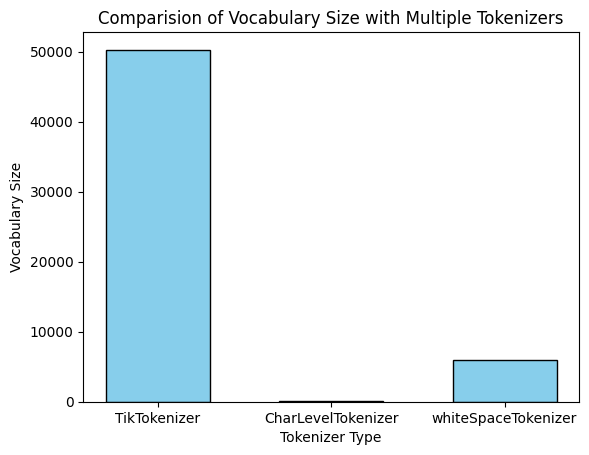

In [ ]:
import os
import requests
import matplotlib.pyplot as plt

#Download the contents of pg11.txt to a file
if not os.path.exists("pg11-contents.txt"):
    url = ("https://www.gutenberg.org/cache/epub/11/pg11.txt")
    file_path = "pg11-contents.txt"

    response = requests.get(url, timeout=30)
    response.raise_for_status()
    with open(file_path, "wb") as f:
        f.write(response.content)
raw_text = open("pg11-contents.txt", "r", encoding="utf-8").read()

#MyTiktokenTokenizer
tiktokenizer = MyTiktokenTokenizer()
token_ids = tiktokenizer.encode(raw_text)
tiktokenizer_compression_ratio = tiktokenizer.calculate_compression_ratio(raw_text,token_ids)
#print('tiktokenizer_compression_ratio',tiktokenizer_compression_ratio)
tiktokenizer_avg_token_length = tiktokenizer.average_token_length(raw_text,token_ids)
#print('tiktokenizer_avg_token_length',tiktokenizer_avg_token_length)
tiktokenizer_vocab_size = tiktokenizer.vocab_size()
#print('tiktokenizer_vocab_size',tiktokenizer_vocab_size)


#White Space Tokenizer
whiteSpaceTokenizer = WhiteSpaceTokenizer()
whiteSpaceTokenizer.build_vocabulary(raw_text)
white_space_token_ids = whiteSpaceTokenizer.encode(raw_text)
white_space_tokenizer_compression_ratio = whiteSpaceTokenizer.calculate_compression_ratio(raw_text,white_space_token_ids)
#print('white_space_tokenizer_compression_ratio',white_space_tokenizer_compression_ratio)
white_space_tokenizer_avg_token_length = whiteSpaceTokenizer.average_token_length(raw_text,white_space_token_ids)
#print('white_space_tokenizer_avg_token_length',white_space_tokenizer_avg_token_length)
white_space_tokenizer_vocab_size = whiteSpaceTokenizer.vocab_size()
#print('white_space_tokenizer_vocab_size',white_space_tokenizer_vocab_size)


#Character Level Tokenizer
vocab = list("abcdefghijklmnopqrstuvwxyzABCDEFGHIJKLMNOPQRSTUVWXYZ!.")  # Vocabulary of all unique characters
charTokenizer = CharacterTokenizer(vocab)
char_token_ids=charTokenizer.encode(raw_text)
charLeveltokenizer_compression_ratio = charTokenizer.calculate_compression_ratio(raw_text,char_token_ids)
#print(f'charLeveltokenizer_compression_ratio',charLeveltokenizer_compression_ratio)
charLeveltokenizer_avg_token_length = charTokenizer.average_token_length(raw_text,char_token_ids)
#print('charLeveltokenizer_avg_token_length',charLeveltokenizer_avg_token_length)
charLeveltokenizer_vocab_size = charTokenizer.vocab_size()
#print('charLeveltokenizer_vocab_size',charLeveltokenizer_vocab_size)

values =[tiktokenizer_vocab_size,charLeveltokenizer_vocab_size,white_space_tokenizer_vocab_size]
categories = ['TikTokenizer', 'CharLevelTokenizer','whiteSpaceTokenizer']
 #Create vertical bar chart
plt.bar(categories, values, color='skyblue', edgecolor='black', width=0.6)

# Labels and title
plt.xlabel('Tokenizer Type')
plt.ylabel('Vocabulary Size')
plt.title('Comparision of Vocabulary Size with Multiple Tokenizers')

# Display the plot
plt.show()


Fundamental Trade off between vocabulary size and sequence length .

**Large Vocabulary: **  
   Input Text will be broken into fewer tokens resulting in shorter sequences. Fewer Sequences will be Linguistically intuitive and readable by humans. Processing will be faster for Short Sequences

** Small Vocabulary: **
Input text will be split into large number of small tokens, resulting in longer sequences (5-10x longer) and it will become computationally expensive and struggle to maintain context over long spans.
Small vocabulary(Character Level) also lack semantic meaning

                                                     ** Assignment-2 **

**Section 1 : Model Parameters : Inference Memory Requirements (16 points)**

In [ ]:
import pandas as mypd
from IPython.display import HTML

# Read Excel
df = mypd.read_excel("/content/Parameter-Census-Table.xlsx",na_filter=False)

# 2. Convert to an HTML table string
html_table = df.to_html(index=False, classes="table table-striped table-hover")

display(HTML(html_table))

Model,Layers (𝐿),𝑑model,Heads,𝑑ff,Vocab (𝑉),Max Seq (𝑇),Total Params
Small,12,768,12,3072,50257,1024,~124M
Medium,24,1024,16,4096,50257,1024,~355M
Large,36,1280,20,5120,50257,1024,~774M
XL,48,1600,25,6400,50257,1024,~1.5B
,,,,,,,
,,,,,,,
,,,,,,,
,,,,,,,
Component,Formula,Small (124M),Medium (355M),Large (774M),XL (1.5B),,
,,,,,,,


In [ ]:
def get_input_embeddings(batch_size, sequence_length, dmodel) :
  return batch_size * sequence_length * dmodel

In [ ]:
def get_Q_K_V_Projection(batch_size,sequence_length,dmodel) :
  return batch_size *3 * sequence_length * dmodel

In [ ]:
def get_attention_Scores(batch_size,heads,sequence_length) :
  return batch_size * heads * sequence_length * sequence_length

In [ ]:
def get_mlp_activations(batch_size, sequence_length, dff) :
  return batch_size * sequence_length * dff

In [ ]:
def getLayerNorm(batch_size,sequence_Length,dmodel) :
  return batch_size *sequence_Length * dmodel

In [ ]:
def get_total_activation_elements(batch_size, heads, sequence_length, dmodel,dff) :
  total_input_embeddings = get_input_embeddings(batch_size, sequence_length, dmodel);
  q_k_v_projections =  get_Q_K_V_Projection(batch_size,sequence_length,dmodel);
  attention_scores = get_attention_Scores(batch_size, heads,sequence_length);
  mlp_activations = get_mlp_activations(batch_size,sequence_length,dff);
  layer_norm = getLayerNorm(batch_size,sequence_length,dmodel);
  return total_input_embeddings + q_k_v_projections + attention_scores + mlp_activations + layer_norm

In [ ]:
def get_peak_activation_memory_for_fp16(total_activation_elements):
  return total_activation_elements * 2

In [ ]:
def get_peak_activation_memory_in_mb_for_fp16(total_activation_elements):
  return total_activation_elements * 2 /(1024 *1024)

In [ ]:
def get_peak_activation_memory_for_fp32(total_activation_elements):
  return total_activation_elements * 4

In [ ]:
def get_peak_activation_memory_in_mb_for_fp32(total_activation_elements):
  return total_activation_elements * 4 /(1024 * 1024)

In [ ]:
def get_Parameter_Memory_for_fp16_in_mb(total_parameters,):
  return total_parameters * (10**6) * 2 / (1024 *1024)

In [ ]:
def get_Parameter_Memory_for_fp32_in_mb(total_parameters):
  return total_parameters * (10**6) * 4 / (1024 *1024)

In [ ]:
def get_activation_memory_parameter_memory_ratio_for_fp16(total_activation_elements,total_parameters):
  return get_peak_activation_memory_in_mb_for_fp16(total_activation_elements)/get_Parameter_Memory_for_fp16_in_mb(total_parameters)

In [ ]:
def get_activation_memory_parameter_memory_ratio_for_fp32(total_activation_elements,total_parameters):
  return get_peak_activation_memory_in_mb_for_fp32(total_activation_elements)/get_Parameter_Memory_for_fp32_in_mb(total_parameters)

In [ ]:
## GPT-2 Small
model_small = "GPT-2 Small"
total_layers_for_small = 12
dmodel_for_small = 768
heads_for_small = 12
dff_for_small = 3072
vocab_for_small = 50,257
max_seq_for_small = 1024
batch_size_for_small = 1
sequence_length_for_small = 1024
total_parameter_count_for_small= 124356864

total_activation_elements_for_small = get_total_activation_elements(batch_size_for_small,heads_for_small,sequence_length_for_small,dmodel_for_small,dff_for_small)
print('total_activation_elements_for_small',total_activation_elements_for_small)

peak_activation_memory_in_mb_for_small_for_fp16 = get_peak_activation_memory_in_mb_for_fp16(total_activation_elements_for_small)
print('peak_activation_memory_in_mb_for_small_for_fp16',peak_activation_memory_in_mb_for_small_for_fp16)

parameter_memory_in_mb_for_small_for_fp16 = get_Parameter_Memory_for_fp16_in_mb(total_activation_elements_for_small)
print('parameter_memory_in_mb_for_small_for_fp16',parameter_memory_in_mb_for_small_for_fp16)

peak_activation_memory_in_mb_for_small_for_fp32 = get_peak_activation_memory_in_mb_for_fp32(total_activation_elements_for_small)
print('peak_activation_memory_in_mb_for_small_for_fp32',peak_activation_memory_in_mb_for_small_for_fp32)

activation_memory_parameter_memory_ratio_for_fp16_for_small = get_activation_memory_parameter_memory_ratio_for_fp16(total_activation_elements_for_small,total_parameter_count_for_small)
print('activation_memory_parameter_memory_ratio_for_fp16_for_small',activation_memory_parameter_memory_ratio_for_fp16_for_small)

activation_memory_parameter_memory_ratio_for_fp32_for_small = get_activation_memory_parameter_memory_ratio_for_fp32(total_activation_elements_for_small,total_parameter_count_for_small)
print('activation_memory_parameter_memory_ratio_for_fp32_for_small',activation_memory_parameter_memory_ratio_for_fp32_for_small)

activation_memory_parameter_memory_ratio_for_fp16_for_small = get_activation_memory_parameter_memory_ratio_for_fp16(total_activation_elements_for_small,total_parameter_count_for_small)
print('activation_memory_parameter_memory_ratio_for_fp16_for_small',activation_memory_parameter_memory_ratio_for_fp16_for_small)

activation_memory_parameter_memory_ratio_for_fp32_for_small = get_activation_memory_parameter_memory_ratio_for_fp32(total_activation_elements_for_small,total_parameter_count_for_small)
print('activation_memory_parameter_memory_ratio_for_fp32_for_small',activation_memory_parameter_memory_ratio_for_fp32_for_small)


total_activation_elements_for_small 19660800
peak_activation_memory_in_mb_for_small_for_fp16 37.5
parameter_memory_in_mb_for_small_for_fp16 37500000.0
peak_activation_memory_in_mb_for_small_for_fp32 75.0
activation_memory_parameter_memory_ratio_for_fp16_for_small 1.5809983757711998e-07
activation_memory_parameter_memory_ratio_for_fp32_for_small 1.5809983757711998e-07
activation_memory_parameter_memory_ratio_for_fp16_for_small 1.5809983757711998e-07
activation_memory_parameter_memory_ratio_for_fp32_for_small 1.5809983757711998e-07


In [ ]:
### Model GPT-2 Medium
model_medium = "GPT-2 Medium"
total_layers_for_medium = 24
dmodel_for_medium = 1024
heads_for_medium = 16
dff_for_medium = 4096
vocab_for_medium = 50257
max_seq_for_medium = 1024
batch_size_for_medium = 1
sequence_length_for_medium = 1024
total_parameter_count_for_medium= 354601984

total_activation_elements_for_medium = get_total_activation_elements(batch_size_for_medium,heads_for_medium,sequence_length_for_medium,dmodel_for_medium,dff_for_medium)
print('total_activation_elements_for_medium',total_activation_elements_for_medium)

peak_activation_memory_in_mb_for_medium_for_fp16 = get_peak_activation_memory_in_mb_for_fp16(total_activation_elements_for_medium)
print('peak_activation_memory_in_mb_for_medium_for_fp16',peak_activation_memory_in_mb_for_medium_for_fp16)

parameter_memory_in_mb_for_medium_for_fp16 = get_Parameter_Memory_for_fp16_in_mb(total_activation_elements_for_medium)
print('parameter_memory_in_mb_for_medium_for_fp16',parameter_memory_in_mb_for_medium_for_fp16)

peak_activation_memory_in_mb_for_medium_for_fp32 = get_peak_activation_memory_in_mb_for_fp32(total_activation_elements_for_medium)
print('peak_activation_memory_in_mb_for_medium_for_fp32',peak_activation_memory_in_mb_for_medium_for_fp32)

activation_memory_parameter_memory_ratio_for_fp16_for_medium = get_activation_memory_parameter_memory_ratio_for_fp16(total_activation_elements_for_medium,total_parameter_count_for_medium)
print('activation_memory_parameter_memory_ratio_for_fp16_for_medium',activation_memory_parameter_memory_ratio_for_fp16_for_medium)

activation_memory_parameter_memory_ratio_for_fp32_for_medium = get_activation_memory_parameter_memory_ratio_for_fp32(total_activation_elements_for_medium,total_parameter_count_for_medium)
print('activation_memory_parameter_memory_ratio_for_fp32_for_medium',activation_memory_parameter_memory_ratio_for_fp32_for_medium)

activation_memory_parameter_memory_ratio_for_fp16_for_medium = get_activation_memory_parameter_memory_ratio_for_fp16(total_activation_elements_for_medium,total_parameter_count_for_medium)
print('activation_memory_parameter_memory_ratio_for_fp16_for_medium',activation_memory_parameter_memory_ratio_for_fp16_for_medium)

activation_memory_parameter_memory_ratio_for_fp32_for_medium = get_activation_memory_parameter_memory_ratio_for_fp32(total_activation_elements_for_medium,total_parameter_count_for_medium)
print('activation_memory_parameter_memory_ratio_for_fp32_for_medium',activation_memory_parameter_memory_ratio_for_fp32_for_medium)

total_activation_elements_for_medium 26214400
peak_activation_memory_in_mb_for_medium_for_fp16 50.0
parameter_memory_in_mb_for_medium_for_fp16 50000000.0
peak_activation_memory_in_mb_for_medium_for_fp32 100.0
activation_memory_parameter_memory_ratio_for_fp16_for_medium 7.392626432682339e-08
activation_memory_parameter_memory_ratio_for_fp32_for_medium 7.392626432682339e-08
activation_memory_parameter_memory_ratio_for_fp16_for_medium 7.392626432682339e-08
activation_memory_parameter_memory_ratio_for_fp32_for_medium 7.392626432682339e-08


In [ ]:
### Model GPT-2 large
model_large = "GPT-2 large"
total_layers_for_large = 24
dmodel_for_large = 1024
heads_for_large = 16
dff_for_large = 4096
vocab_for_large = 50257
max_seq_for_large = 1024
batch_size_for_large = 1
sequence_length_for_large = 1024
total_parameter_count_for_large= 354601984

total_activation_elements_for_large = get_total_activation_elements(batch_size_for_large,heads_for_large,sequence_length_for_large,dmodel_for_large,dff_for_large)
print('total_activation_elements_for_large',total_activation_elements_for_large)

peak_activation_memory_in_mb_for_large_for_fp16 = get_peak_activation_memory_in_mb_for_fp16(total_activation_elements_for_large)
print('peak_activation_memory_in_mb_for_large_for_fp16',peak_activation_memory_in_mb_for_large_for_fp16)

parameter_memory_in_mb_for_large_for_fp16 = get_Parameter_Memory_for_fp16_in_mb(total_activation_elements_for_large)
print('parameter_memory_in_mb_for_large_for_fp16',parameter_memory_in_mb_for_large_for_fp16)

peak_activation_memory_in_mb_for_large_for_fp32 = get_peak_activation_memory_in_mb_for_fp32(total_activation_elements_for_large)
print('peak_activation_memory_in_mb_for_large_for_fp32',peak_activation_memory_in_mb_for_large_for_fp32)

activation_memory_parameter_memory_ratio_for_fp16_for_large = get_activation_memory_parameter_memory_ratio_for_fp16(total_activation_elements_for_large,total_parameter_count_for_large)
print('activation_memory_parameter_memory_ratio_for_fp16_for_large',activation_memory_parameter_memory_ratio_for_fp16_for_large)

activation_memory_parameter_memory_ratio_for_fp32_for_large = get_activation_memory_parameter_memory_ratio_for_fp32(total_activation_elements_for_large,total_parameter_count_for_large)
print('activation_memory_parameter_memory_ratio_for_fp32_for_large',activation_memory_parameter_memory_ratio_for_fp32_for_large)

activation_memory_parameter_memory_ratio_for_fp16_for_large = get_activation_memory_parameter_memory_ratio_for_fp16(total_activation_elements_for_large,total_parameter_count_for_large)
print('activation_memory_parameter_memory_ratio_for_fp16_for_large',activation_memory_parameter_memory_ratio_for_fp16_for_large)

activation_memory_parameter_memory_ratio_for_fp32_for_large = get_activation_memory_parameter_memory_ratio_for_fp32(total_activation_elements_for_large,total_parameter_count_for_large)
print('activation_memory_parameter_memory_ratio_for_fp32_for_large',activation_memory_parameter_memory_ratio_for_fp32_for_large)



total_activation_elements_for_large 26214400
peak_activation_memory_in_mb_for_large_for_fp16 50.0
parameter_memory_in_mb_for_large_for_fp16 50000000.0
peak_activation_memory_in_mb_for_large_for_fp32 100.0
activation_memory_parameter_memory_ratio_for_fp16_for_large 7.392626432682339e-08
activation_memory_parameter_memory_ratio_for_fp32_for_large 7.392626432682339e-08
activation_memory_parameter_memory_ratio_for_fp16_for_large 7.392626432682339e-08
activation_memory_parameter_memory_ratio_for_fp32_for_large 7.392626432682339e-08


In [ ]:
### Model GPT-2 xl
model_xl = "GPT-2 xl"
total_layers_for_xl = 24
dmodel_for_xl = 1024
heads_for_xl = 16
dff_for_xl = 4096
vocab_for_xl = 50257
max_seq_for_xl = 1024
batch_size_for_xl = 1
sequence_length_for_xl = 1024
total_parameter_count_for_xl= 354601984

total_activation_elements_for_xl = get_total_activation_elements(batch_size_for_xl,heads_for_xl,sequence_length_for_xl,dmodel_for_xl,dff_for_xl)
print('total_activation_elements_for_xl',total_activation_elements_for_xl)

peak_activation_memory_in_mb_for_xl_for_fp16 = get_peak_activation_memory_in_mb_for_fp16(total_activation_elements_for_xl)
print('peak_activation_memory_in_mb_for_xl_for_fp16',peak_activation_memory_in_mb_for_xl_for_fp16)

parameter_memory_in_mb_for_xl_for_fp16 = get_Parameter_Memory_for_fp16_in_mb(total_activation_elements_for_xl)
print('parameter_memory_in_mb_for_xl_for_fp16',parameter_memory_in_mb_for_xl_for_fp16)

peak_activation_memory_in_mb_for_xl_for_fp32 = get_peak_activation_memory_in_mb_for_fp32(total_activation_elements_for_xl)
print('peak_activation_memory_in_mb_for_xl_for_fp32',peak_activation_memory_in_mb_for_xl_for_fp32)

activation_memory_parameter_memory_ratio_for_fp16_for_xl = get_activation_memory_parameter_memory_ratio_for_fp16(total_activation_elements_for_xl,total_parameter_count_for_xl)
print('activation_memory_parameter_memory_ratio_for_fp16_for_xl',activation_memory_parameter_memory_ratio_for_fp16_for_xl)

activation_memory_parameter_memory_ratio_for_fp32_for_xl = get_activation_memory_parameter_memory_ratio_for_fp32(total_activation_elements_for_xl,total_parameter_count_for_xl)
print('activation_memory_parameter_memory_ratio_for_fp32_for_xl',activation_memory_parameter_memory_ratio_for_fp32_for_xl)

activation_memory_parameter_memory_ratio_for_fp16_for_xl = get_activation_memory_parameter_memory_ratio_for_fp16(total_activation_elements_for_xl,total_parameter_count_for_xl)
print('activation_memory_parameter_memory_ratio_for_fp16_for_xl',activation_memory_parameter_memory_ratio_for_fp16_for_xl)

activation_memory_parameter_memory_ratio_for_fp32_for_xl = get_activation_memory_parameter_memory_ratio_for_fp32(total_activation_elements_for_xl,total_parameter_count_for_xl)
print('activation_memory_parameter_memory_ratio_for_fp32_for_xl',activation_memory_parameter_memory_ratio_for_fp32_for_xl)

total_activation_elements_for_xl 26214400
peak_activation_memory_in_mb_for_xl_for_fp16 50.0
parameter_memory_in_mb_for_xl_for_fp16 50000000.0
peak_activation_memory_in_mb_for_xl_for_fp32 100.0
activation_memory_parameter_memory_ratio_for_fp16_for_xl 7.392626432682339e-08
activation_memory_parameter_memory_ratio_for_fp32_for_xl 7.392626432682339e-08
activation_memory_parameter_memory_ratio_for_fp16_for_xl 7.392626432682339e-08
activation_memory_parameter_memory_ratio_for_fp32_for_xl 7.392626432682339e-08


**Task 2: Activation Memory Analysis**

**Peak_activation_memory_in_mb_for_small_for_fp16:  37.5**

**Peak_activation_memory_in_mb_for_small_for_fp32 : 75.0**


Ratio of activation memory to parameter memory for GPT-2 Small (FP16):  1.5809983757711998e-07

Ratio of activation memory to parameter memory for GPT-2 Small (FP32): 1.5809983757711998e-07

Ratio of activation memory to parameter memory for GPT-2 Medium (FP16) : 7.392626432682339e-08

Ratio of activation memory to parameter memory for GPT-2 Medium (FP32) : 7.392626432682339e-08

Ratio of activation memory to parameter memory for GPT-2 Large (FP16) : 7.392626432682339e-08

Ratio of activation memory to parameter memory for GPT-2 Large (FP32) : 7.392626432682339e-08

Ratio of activation memory to parameter memory for GPT-2 XL (FP16) : 7.392626432682339e-08

Ratio of activation memory to parameter memory for GPT-2 XL (FP32) : 7.392626432682339e-08

**At what model size do activations become negligible compared to parameters**

Activations become negligible when model parameters are in the range of 1B-3B parameters with the batch size of 1 and moderate sequence lengths of 1K-4K

**Task 3: Scaling Laws**

Verify your parameter counts match the reference values (±0.1%):

Expected Small: 124439808 - Actual Small : 124356864 -- Percentage Difference : 0.000666539

Expected Medium: 354823168 - Actual Medium : 354601984 -- Percentage Difference : 0.000623364

Expected Large: 773903616 - Actual Large : 773615360 -- Percentage Difference: 0.00037247

**Plot parameter count vs. FP16 memory for all three models on a log-log scale**


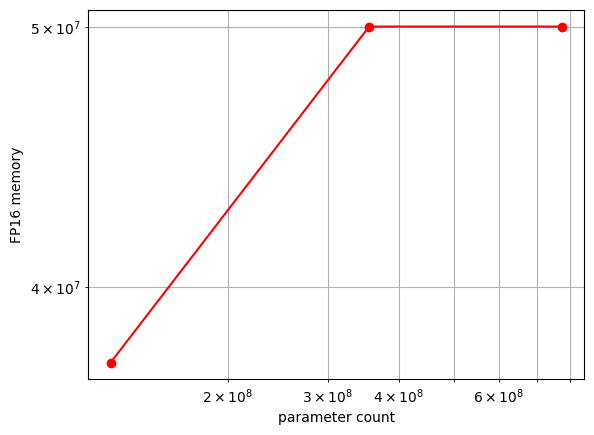

In [ ]:
import matplotlib.pyplot as plt

parameter_count_for_small = 124439808
parameter_count_for_medium = 354823168
parameter_count_for_large: 773903616

parameter_count_array_for_models = [124439808,354823168,773903616]

fp_16_memory_for_models = [37500000.0,50000000.0,50000000.0]

plt.plot(parameter_count_array_for_models, fp_16_memory_for_models, 'ro-')

# Convert both axes to log scale
plt.xscale('log')
plt.yscale('log')
plt.xlabel("parameter count")
plt.ylabel("FP16 memory")

plt.grid(True, which="both")
plt.show()


**Analysis :**
Why does the Medium model use ~2.9× the memory of Small, but Large only uses ~2.2× the memory of Medium, despite both adding 12 layers

**Analysis Comments:** The non-linear memory scaling between model sizes happens because embedding layers occupy a fixed amount of memory, while transformer blocks scale quadratically with the hidden dimension dmodel

When you add layers, you are not just adding depth L you are also increasing width dmodel and attention heads.

**Small to Medium (~2.9× memory increase)**

Number of Layeres(L) increases from 12 to 24 (2.0× depth).
dmodel increases from 768 to 1024 (1.33× width).
Because transformer layer memory scales with the square of the width (dmodel^2), each Medium layer is roughly 1.78× larger than a Small layer.Combining 2.0× depth with 1.78× layer size creates a massive jump in transformer block memory, easily overpowering the static embedding overhead.

**Medium to Large (~2.2× memory increase):**

Number of Layeres (L) increases from 24 to 32 (1.33× depth)
dmodel increases from 1024 to 1280
Each Large layer is roughly 1.56× larger than a Medium layer
The relative jump in both depth (1.33× vs 2.0×) and width (1.25× vs 1.33×) is significantly smaller than the jump from Small to Medium.


**<span style="color: blue;font-size: 30px;">Section 2: From CPU to GPU : Inference Profiling & Optimization</span>**

In [ ]:
import torch
print(f"PyTorch: {torch.__version__}")
print(f"CUDA Available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
  print(f"Device: {torch.cuda.get_device_name(0)}")
  print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")

PyTorch: 2.11.0+cpu
CUDA Available: False


In [ ]:
!nvidia-smi --query-gpu=name,memory.total,memory.free --format=csv

/bin/bash: line 1: nvidia-smi: command not found


In [ ]:
# Helper to get current RAM usage in MB
def get_ram_usage():
    process = psutil.Process(os.getpid())
    return process.memory_info().rss / (1024 ** 2)

** Task 1: CPU Baseline (5 points) **
Run inference on the CPU only (disable CUDA or use map_location='cpu').
Test all three model sizes with the following setup:

**Input: Batch size = 1, sequence length = 512 (any prompt or text from above book) generate 128 new tokens autoregressively**

Metrics to collect:
*   Cold-start latency (time to first token, TTFT)
*   Steady-state latency (average latency over tokens 10–50, ITL)
*   Throughput (tokens/sec)
*   System RAM usage (psutil or torch.cuda.memory_allocated())

Important: Use torch.no_grad() throughout. Run 2 warm-up forward passes before timing.

In [ ]:
import time
import psutil
import torch
import os
import requests
from transformers import AutoTokenizer, AutoModelForCausalLM

# --------------------------------------------------
# Configuration
# --------------------------------------------------

list_of_models = ["gpt2","gpt2-medium","gpt2-large"]
sequence_length = 512
new_tokens = 128

## Parse the URL and download the contents of https://www.gutenberg.org/cache/epub/11/pg11.txt
#Download the contents of pg11.txt to a file
if not os.path.exists("pg11-contents.txt"):
    url = ("https://www.gutenberg.org/cache/epub/11/pg11.txt")
    file_path = "pg11-contents.txt"
    response = requests.get(url, timeout=30)
    response.raise_for_status()
    with open(file_path, "wb") as f:
        f.write(response.content)
input_text = open("pg11-contents.txt", "r", encoding="utf-8").read(sequence_length)


def get_ram_mb():
    process = psutil.Process()
    return process.memory_info().rss / 1024**2


def benchmark_model(model_name):
    print(f"\n{'='*60}")
    print(model_name)
    print(f"{'='*60}")

    tokenizer = AutoTokenizer.from_pretrained(model_name)

    model = AutoModelForCausalLM.from_pretrained(
        model_name,
        torch_dtype=torch.float32,
        device_map="cpu"
    )

    model = model.cpu()
    model.eval()

    # Create exactly 512-token input
    encoded = tokenizer(input_text,return_tensors="pt",truncation=True,max_length=sequence_length)
    input_ids = encoded["input_ids"]

    if input_ids.shape[1] < sequence_length:
        repeats = (sequence_length // input_ids.shape[1]) + 1
        input_ids = input_ids.repeat(1, repeats)[:, :sequence_length]

    attention_mask = torch.ones_like(input_ids)

    # ------------------------------------------
    # Warm-up passes (required)
    # ------------------------------------------
    with torch.no_grad():
        for index in range(2):
            index = model(input_ids=input_ids,attention_mask=attention_mask,use_cache=True,)

    # ------------------------------------------
    # Autoregressive generation
    # ------------------------------------------
    generated = input_ids.clone()
    attn = attention_mask.clone()

    token_latencies = []

    with torch.no_grad():
        # First token (TTFT)
        start_ttft = time.perf_counter()

        outputs = model(input_ids=generated,attention_mask=attn,use_cache=True,)
        next_token = outputs.logits[:, -1].argmax(dim=-1, keepdim=True)
        past_key_values = outputs.past_key_values

        ttft = time.perf_counter() - start_ttft

        generated = torch.cat([generated, next_token], dim=1)
        attn = torch.cat(
            [attn, torch.ones((1, 1), dtype=attn.dtype)],
            dim=1,
        )

        # Remaining tokens
        generation_start = time.perf_counter()
        for index in range(new_tokens - 1):
            step_start = time.perf_counter()

            outputs = model(
                input_ids=next_token,
                past_key_values=past_key_values,
                use_cache=True,
            )

            next_token = outputs.logits[:, -1].argmax(
                dim=-1,
                keepdim=True,
            )

            past_key_values = outputs.past_key_values
            token_latencies.append(time.perf_counter() - step_start)

        generation_time = time.perf_counter() - generation_start

    # ------------------------------------------
    # Metrics
    # ------------------------------------------

    # Token indices 10–50 inclusive
    # After first token, token_latencies[0] corresponds to generated token #2
    # Therefore generated tokens 10..50 => indices 8..48
    itl_window = token_latencies[8:49]

    steady_state_itl = (
        sum(itl_window) / len(itl_window)
        if len(itl_window) > 0
        else float("nan")
    )

    total_generation_time = ttft + generation_time
    throughput = new_tokens / total_generation_time
    ram_mb = get_ram_mb()

    print(f"TTFT:              {ttft:.4f} s")
    print(f"ITL (tok 10-50):   {steady_state_itl*1000:.2f} ms/token")
    print(f"total_generation_time: {total_generation_time:.4f}")
    print(f"Throughput:        {throughput:.2f} tokens/sec")
    print(f"RAM Usage:         {ram_mb:.2f} MB")

    return {"model": model_name,"ttft_s": ttft,"itl_ms": steady_state_itl * 1000,
            "total_generation_time": total_generation_time, "throughput_tps": throughput,"ram_mb": ram_mb,}


if __name__ == "__main__":
    results = []

    # Disable CUDA completely
    torch.set_grad_enabled(False)

    for model_name in list_of_models:
        results.append(benchmark_model(model_name))

    print("\n\nSummary")
    print("-" * 80)

    for r in results:
        print(
            f"{r['model']:25s} "
            f"TTFT={r['ttft_s']:.3f}s "
            f"total generation time={r['total_generation_time']:.3f}s "
            f"ITL={r['itl_ms']:.2f}ms  "
            f"TPS={r['throughput_tps']:.2f}  "
            f"RAM={r['ram_mb']:.1f}MB "
        )



gpt2


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

TTFT:              2.9274 s
ITL (tok 10-50):   70.10 ms/token
total_generation_time: 12.1588
Throughput:        10.53 tokens/sec
RAM Usage:         2026.36 MB

gpt2-medium


Loading weights:   0%|          | 0/292 [00:00<?, ?it/s]

TTFT:              8.3390 s
ITL (tok 10-50):   205.32 ms/token
total_generation_time: 33.8830
Throughput:        3.78 tokens/sec
RAM Usage:         2983.33 MB

gpt2-large


Loading weights:   0%|          | 0/436 [00:00<?, ?it/s]

TTFT:              17.9892 s
ITL (tok 10-50):   401.18 ms/token
total_generation_time: 70.0935
Throughput:        1.83 tokens/sec
RAM Usage:         4700.22 MB


Summary
--------------------------------------------------------------------------------
gpt2                      TTFT=2.927s total generation time=12.159s ITL=70.10ms  TPS=10.53  RAM=2026.4MB 
gpt2-medium               TTFT=8.339s total generation time=33.883s ITL=205.32ms  TPS=3.78  RAM=2983.3MB 
gpt2-large                TTFT=17.989s total generation time=70.094s ITL=401.18ms  TPS=1.83  RAM=4700.2MB 


Model     ----       First Token Latency  ---       Throughput (tok/s)        ---  RAM Used

Small 124M ----          2.927s   ---               10.53            ---2026.4MB -                         -

Medium 355M   ----        8.339s    ---             3.78             ---2983.3MB        -     

Large 774M   ----         17.989s   ---             1.83            --- 4700 MB

**Task 2: GPU Migration & Basic Acceleration (5 points**)

Move each model to the T4 GPU (model = model.cuda()) and repeat the same generation task.
Measure:

*   Device transfer time: Time moving parameters from CPU RAM -> GPU VRAM (use time.time() before and after .cuda())
*   Inference throughput: Same task as Task 1; use torch.cuda.synchronize() before and after generation
*   Peak VRAM usage: torch.cuda.max_memory_allocated() after each run
*   Compute the speedup ratio (CPU time / GPU time) for each model size.

Analyse this: Does speedup scale linearly with model size? Why does the Large model hit higher throughput while Small only manages lower throughput gains? (Hint: fixed GPU overhead dominates for small models.)

In [ ]:
import time
import psutil
import torch
import os
import requests
from transformers import AutoTokenizer, AutoModelForCausalLM

# --------------------------------------------------
# Configuration
# --------------------------------------------------

list_of_models = ["gpt2","gpt2-medium","gpt2-large"]
sequence_length = 512
new_tokens = 128
cpu_times={'gpt2':12.159,
           'gpt2-medium': 33.883,
           'gpt2-large':70.094
          }
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
## Parse the URL and download the contents of https://www.gutenberg.org/cache/epub/11/pg11.txt
#Download the contents of pg11.txt to a file
if not os.path.exists("pg11-contents.txt"):
    url = ("https://www.gutenberg.org/cache/epub/11/pg11.txt")
    file_path = "pg11-contents.txt"
    response = requests.get(url, timeout=30)
    response.raise_for_status()
    with open(file_path, "wb") as f:
        f.write(response.content)
input_text = open("pg11-contents.txt", "r", encoding="utf-8").read(sequence_length)

# --------------------------------------------------
# Benchmark
# --------------------------------------------------
def get_ram_mb():
    process = psutil.Process()
    return process.memory_info().rss / 1024**2

def benchmark_model(model_name):
    print(f"\n{'='*60}")
    print(model_name)
    print(f"{'='*60}")

    tokenizer = AutoTokenizer.from_pretrained(model_name)
    start = time.perf_counter()

    model = AutoModelForCausalLM.from_pretrained(
        model_name,
        torch_dtype=torch.float16,).to(device)

    model.eval()

    # Create exactly 512-token input
    encoded = tokenizer(input_text,return_tensors="pt",truncation=True,max_length=sequence_length)
    input_ids = encoded["input_ids"]

    if input_ids.shape[1] < sequence_length:
        repeats = (sequence_length // input_ids.shape[1]) + 1
        input_ids = input_ids.repeat(1, repeats)[:, :sequence_length]

    attention_mask = torch.ones_like(input_ids)

    input_ids = input_ids.to(device)
    attention_mask = attention_mask.to(device)

     # Reset peak memory stats
    torch.cuda.empty_cache()
    torch.cuda.reset_peak_memory_stats()

    # ------------------------------------------
    # Warm-up passes (required)
    # ------------------------------------------
    with torch.no_grad():
        for index in range(2):
            index = model(input_ids=input_ids,attention_mask=attention_mask,use_cache=True,)

    # ------------------------------------------
    # Autoregressive generation
    # ------------------------------------------
    generated = input_ids.clone()
    attn = attention_mask.clone()

    token_latencies = []

    with torch.no_grad():
        # First token (TTFT)
        start = time.perf_counter()
        start_ttft = time.perf_counter()
        outputs = model(input_ids=generated,attention_mask=attn,use_cache=True,)
        next_token = outputs.logits[:, -1].argmax(dim=-1, keepdim=True)
        past_key_values = outputs.past_key_values
        torch.cuda.synchronize()

        ttft = time.perf_counter() - start_ttft

        generated = torch.cat([generated, next_token], dim=1)

        # Remaining tokens
        generation_start = time.perf_counter()

        for index in range(new_tokens - 1):
            torch.cuda.synchronize()
            step_start = time.perf_counter()
            outputs = model(input_ids=next_token,past_key_values=past_key_values,use_cache=True,)
            next_token = outputs.logits[:, -1].argmax(
                dim=-1,
                keepdim=True,
            )
            past_key_values = outputs.past_key_values
            torch.cuda.synchronize()
            token_latencies.append(time.perf_counter() - step_start)

        generation_time = time.perf_counter() - generation_start

    # ------------------------------------------
    # Metrics
    # ------------------------------------------

    # Token indices 10–50 inclusive
    # After first token, token_latencies[0] corresponds to generated token #2
    # Therefore generated tokens 10..50 => indices 8..48

    itl_window = token_latencies[8:49]
    itl = sum(itl_window) / len(itl_window)
    throughput = new_tokens / (ttft + generation_time)
    steady_state_itl = (
        sum(itl_window) / len(itl_window)
        if len(itl_window) > 0
        else float("nan")
    )

    total_generation_time = ttft + generation_time
    throughput = new_tokens / total_generation_time
    ram_mb = get_ram_mb()

    gpu_mem_mb = (
        torch.cuda.memory_allocated() / 1024**2
    )

    gpu_peak_mem_mb = (
        torch.cuda.max_memory_allocated() / 1024**2
    )

    peak_vram_usage = (
        torch.cuda.max_memory_allocated() / (1024 ** 3) # Converted to GB
    )

    speed_up_ratio = (
        cpu_times[model_name] / total_generation_time
    )

    print(f"TTFT:                  {ttft:.4f} s")
    print(f"ITL (10-50):           {itl*1000:.2f} ms")
    print(f"Device Transfer Rate:  {generation_time:.2f}s")
    print(f"Total Generation time: {total_generation_time:.4f} s")
    print(f"Inference throughput:  {throughput:.2f} tok/s")
    print(f"GPU Memory:            {gpu_mem_mb:.2f} MB")
    print(f"Speed Up Ratio:        {speed_up_ratio:.2f}")
    print(f"Peak GPU Memory:       {gpu_peak_mem_mb:.2f} MB")
    print(f"peak_vram_usage:       {peak_vram_usage:.2f} MB")

    return {
        "model": model_name,
        "ttft_s": ttft,
        "itl_ms": itl * 1000,
        "speed_up_ratio": speed_up_ratio,
        "Device_Transfer_Rate": generation_time,
        "total_generation_time:" :total_generation_time,
        "Inference throughput": throughput,
        "gpu_mem_mb": gpu_mem_mb,
        "peak_gpu_mem_mb": gpu_peak_mem_mb,
        "peak_vram_usage": peak_vram_usage
    }


if __name__ == "__main__":
    results = []

    for model_name in list_of_models:
        results.append(benchmark_model(model_name))

    print("\n\nSummary")
    print("-" * 80)

    for r in results:
      print(r)


gpt2


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:124: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

...

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/3.25G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/436 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

TTFT:                  0.0922 s
ITL (10-50):           30.51 ms
Device Transfer Rate:  4.34s
Total Generation time: 4.4369 s
Inference throughput:  28.85 tok/s
GPU Memory:            1598.47 MB
Speed Up Ratio:        15.80
Peak GPU Memory:       1776.41 MB
peak_vram_usage:       1.73 MB


Summary
--------------------------------------------------------------------------------
{'model': 'gpt2', 'ttft_s': 0.03910243099994659, 'itl_ms': 9.35969995122455, 'speed_up_ratio': 8.607318757622306, 'Device_Transfer_Rate': 1.373532599999976, 'total_generation_time:': 1.4126350309999225, 'Inference throughput': 90.61080689001193, 'gpu_mem_mb': 275.18408203125, 'peak_gpu_mem_mb': 389.3720703125, 'peak_vram_usage': 0.3802461624145508}
{'model': 'gpt2-medium', 'ttft_s': 0.054153346000020974, 'itl_ms': 23.68706058536102, 'speed_up_ratio': 12.008867353608116, 'Device_Transfer_Rate': 2.767345051999996, 'total_generation_time:': 2.821498398000017, 'Inference throughput': 45.3659658608104, 'gpu_mem_mb': 74

**Measure:**
*   Device transfer time: Time moving parameters from CPU RAM -> GPU VRAM (use time.time() before and after .cuda())
*   Inference throughput: Same task as Task 1; use torch.cuda.synchronize() before and after generation
*   Peak VRAM usage: torch.cuda.max_memory_allocated() after each run
*   Compute the speedup ratio (CPU time / GPU time) for each model size.


Model --------- Device Transfer Time --------- Inference throughput  --------- Peak VRAM usage --------- speedup ratio
--------------------------------------------------------------------------------

---

gpt2         ---------  1.373532599999976 --------- 90.61080689001193  --------- 0.3802461624145508 --------- 8.607318757622306

gpt2-medium  --------- 2.767345051999996 --------- 45.3659658608104 ---------0.8622188568115234 --------- 12.008867353608116

gpt2-large   --------- 4.344727979000027 ---------28.84890064637784 ---------1.7347784042358398 ---------15.797928452400063

**Task 3: Optimization Experiments (4 points)**

Apply the following optimizations to the Medium model (355M). For each, measure the change in tokens/sec and VRAM relative to the FP32 GPU baseline.

**Option A: Mixed Precision (FP16)**

model = model.half().cuda() # Convert weights to FP16with torch.no_grad():

outputs = model.generate(...)

*   Measure speedup vs. FP32 (expect ~1.5–2× on T4 due to Tensor Cores)
*   Check output quality: compute perplexity on a test sentence and confirm it stays within 1% of FP32


**FP32 Baseline**

In [ ]:
import time
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM

MODEL_NAME = "gpt2-medium"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForCausalLM.from_pretrained(MODEL_NAME).cuda().eval()

prompt = "The future of artificial intelligence is"
inputs = tokenizer(prompt, return_tensors="pt").to("cuda")

torch.cuda.reset_peak_memory_stats()

torch.cuda.synchronize()
start = time.perf_counter()

with torch.no_grad():
    output = model.generate(
        **inputs,
        max_new_tokens=128,
        do_sample=False
    )

torch.cuda.synchronize()
elapsed = time.perf_counter() - start

tokens_generated = output.shape[1] - inputs["input_ids"].shape[1]

fp32_tps = tokens_generated / elapsed
fp32_vram = torch.cuda.max_memory_allocated() / 1024**2

print(f"FP32 TPS = {fp32_tps:.2f}")
print(f"FP32 VRAM = {fp32_vram:.1f} MB")

Loading weights:   0%|          | 0/292 [00:00<?, ?it/s]

[transformers] Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


FP32 TPS = 27.08
FP32 VRAM = 1388.3 MB


** FP16 BenchMark **

In [ ]:
model_fp16 = (
    AutoModelForCausalLM
    .from_pretrained(MODEL_NAME)
    .half()
    .cuda()
    .eval()
)

torch.cuda.reset_peak_memory_stats()

torch.cuda.synchronize()
start = time.perf_counter()

with torch.no_grad():
    output = model_fp16.generate(
        **inputs,
        max_new_tokens=128,
        do_sample=False
    )

torch.cuda.synchronize()
elapsed = time.perf_counter() - start

tokens_generated = output.shape[1] - inputs["input_ids"].shape[1]

fp16_tps = tokens_generated / elapsed
fp16_vram = torch.cuda.max_memory_allocated() / 1024**2

print(f"FP16 TPS = {fp16_tps:.2f}")
print(f"FP16 VRAM = {fp16_vram:.1f} MB")

Loading weights:   0%|          | 0/292 [00:00<?, ?it/s]

[transformers] Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


FP16 TPS = 45.56
FP16 VRAM = 2052.4 MB


** SpeedUp Calculation **


In [ ]:
speedup = fp16_tps / fp32_tps

print(f"Speedup = {speedup:.2f}x")

vram_reduction = 100 * (fp32_vram - fp16_vram) / fp32_vram

print(f"VRAM reduction = {vram_reduction:.1f}%")

Speedup = 1.68x
VRAM reduction = -47.8%


**Perplexity Comparison**

In [ ]:
import math

test_text = """
Large language models have transformed the field of natural language processing.
"""
enc = tokenizer(test_text, return_tensors="pt")

def perplexity(model):
    ids = enc["input_ids"].to(next(model.parameters()).device)

    with torch.no_grad():
        loss = model(ids, labels=ids).loss

    return math.exp(loss.item())

ppl_fp32 = perplexity(model)
ppl_fp16 = perplexity(model_fp16)

print("FP32 PPL:", ppl_fp32)
print("FP16 PPL:", ppl_fp16)

pct_diff = abs(ppl_fp32 - ppl_fp16) / ppl_fp32 * 100

print("Difference %:", pct_diff)

[transformers] `loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.


FP32 PPL: 50.87224420654144
FP16 PPL: 50.91624257075962
Difference %: 0.08648795606411516


** Option B: Batch Size Scaling **

Test batch sizes: [1, 2, 4, 8, 16] (stop if OOM)

*   Plot throughput (tokens/sec) vs. batch size
*   Mark the saturation point where adding more to the batch stops helping
*   Compute per-token latency at each batch size and discuss the latency/throughput trade-off


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

[transformers] Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
[transformers] Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
[transformers] Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
[transformers] Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
[transformers] Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
[transformers] Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
[transformers] Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
[transformers] Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
[transformers] Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
[transformers] Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
[transformers] Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
[transformers] Setting `pad_token_id` to `e


Benchmark Results
 Batch Size   Time (s)  Throughput (tok/s)  Latency per Token (s)
          1  10.824527           11.824997               0.084567
          2  34.014518            7.526198               0.265738
          4  60.977851            8.396491               0.476389
          8  55.232040           18.539964               0.431500
         16  95.704247           21.399259               0.747689
         32 243.745212           16.804433               1.904259

Estimated Saturation Batch Size: 2


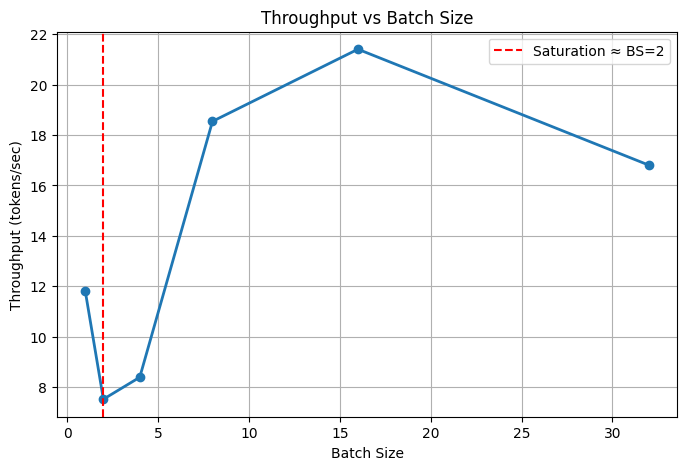

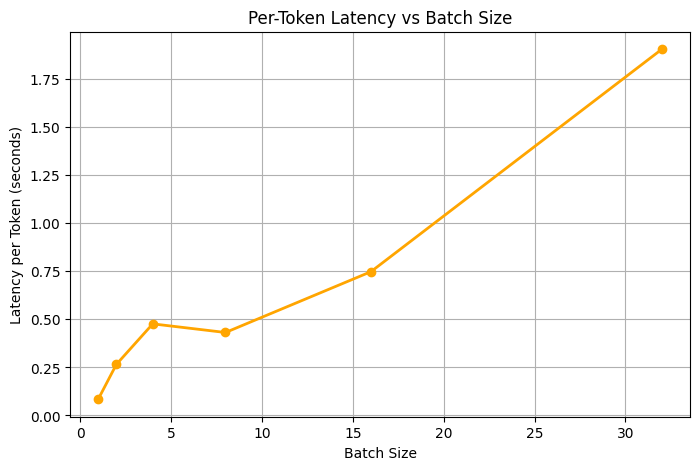

In [ ]:
import time
import torch
import pandas as pd
import matplotlib.pyplot as plt
from transformers import AutoTokenizer, AutoModelForCausalLM

# --------------------------------------------------
# Configuration
# --------------------------------------------------
MODEL_NAME = "gpt2"  # replace with your model
SEQ_LEN = 512
NEW_TOKENS = 128
BATCH_SIZES = [1, 2, 4, 8, 16,32]
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# --------------------------------------------------
# Load model
# --------------------------------------------------
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token
model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    torch_dtype=torch.float16 if DEVICE == "cuda" else torch.float32
).to(DEVICE)

model.eval()

# --------------------------------------------------
# Create fixed 512-token prompt
# --------------------------------------------------
text = "The quick brown fox jumps over the lazy dog. "

tokens = tokenizer(text, return_tensors="pt")["input_ids"][0]

repeat_factor = (SEQ_LEN // len(tokens)) + 1
prompt_ids = tokens.repeat(repeat_factor)[:SEQ_LEN]

results = []

# --------------------------------------------------
# Benchmark
# --------------------------------------------------
for batch_size in BATCH_SIZES:

    input_ids = prompt_ids.unsqueeze(0).repeat(batch_size, 1).to(DEVICE)
    attention_mask = torch.ones_like(input_ids)

    # Warmup
    with torch.no_grad():
        _ = model.generate(
            input_ids,
            attention_mask=attention_mask,
            max_new_tokens=8,
            do_sample=False
        )

    torch.cuda.synchronize() if DEVICE == "cuda" else None

    start = time.perf_counter()

    with torch.no_grad():
        _ = model.generate(
            input_ids,
            attention_mask=attention_mask,
            max_new_tokens=NEW_TOKENS,
            do_sample=False
        )

    torch.cuda.synchronize() if DEVICE == "cuda" else None

    end = time.perf_counter()

    elapsed = end - start

    total_generated_tokens = batch_size * NEW_TOKENS

    throughput = total_generated_tokens / elapsed

    latency_per_token = elapsed / NEW_TOKENS

    results.append({
        "Batch Size": batch_size,
        "Time (s)": elapsed,
        "Throughput (tok/s)": throughput,
        "Latency per Token (s)": latency_per_token
    })

# --------------------------------------------------
# Results table
# --------------------------------------------------
df = pd.DataFrame(results)

print("\nBenchmark Results")
print(df.to_string(index=False))

# --------------------------------------------------
# Saturation point
# --------------------------------------------------
throughputs = df["Throughput (tok/s)"].values

saturation_batch = None

for i in range(1, len(throughputs)):
    improvement = (
        (throughputs[i] - throughputs[i - 1])
        / throughputs[i - 1]
    )

    if improvement < 0.10:  # <10% gain
        saturation_batch = BATCH_SIZES[i]
        break

print(f"\nEstimated Saturation Batch Size: {saturation_batch}")

# --------------------------------------------------
# Plot Throughput
# --------------------------------------------------
plt.figure(figsize=(8, 5))
plt.plot(
    df["Batch Size"],
    df["Throughput (tok/s)"],
    marker="o",
    linewidth=2
)

if saturation_batch is not None:
    sat_tp = df.loc[
        df["Batch Size"] == saturation_batch,
        "Throughput (tok/s)"
    ].values[0]

    plt.axvline(
        saturation_batch,
        linestyle="--",
        color="red",
        label=f"Saturation ≈ BS={saturation_batch}"
    )

plt.xlabel("Batch Size")
plt.ylabel("Throughput (tokens/sec)")
plt.title("Throughput vs Batch Size")
plt.grid(True)
plt.legend()
plt.show()

# --------------------------------------------------
# Plot Latency
# --------------------------------------------------
plt.figure(figsize=(8, 5))
plt.plot(
    df["Batch Size"],
    df["Latency per Token (s)"],
    marker="o",
    linewidth=2,
    color="orange"
)

plt.xlabel("Batch Size")
plt.ylabel("Latency per Token (seconds)")
plt.title("Per-Token Latency vs Batch Size")
plt.grid(True)
plt.show()


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:124: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/718 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

...

model.safetensors:   0%|          | 0.00/1.52G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/292 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

[transformers] Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
[transformers] Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
[transformers] Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
[transformers] Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
[transformers] Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
[transformers] Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
[transformers] Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
[transformers] Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
[transformers] Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
[transformers] Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
[transformers] Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
[transformers] Setting `pad_token_id` to `e


Benchmark Results
 Batch Size  Time (s)  Throughput (tok/s)  Latency per Token (s)
          1  2.169961           58.987232               0.016953
          2  2.216488          115.498026               0.017316
          4  3.005631          170.346944               0.023481
          8  2.365400          432.907779               0.018480
         16  3.325064          615.928082               0.025977
         32  6.087287          672.877742               0.047557

Estimated Saturation Batch Size: 32


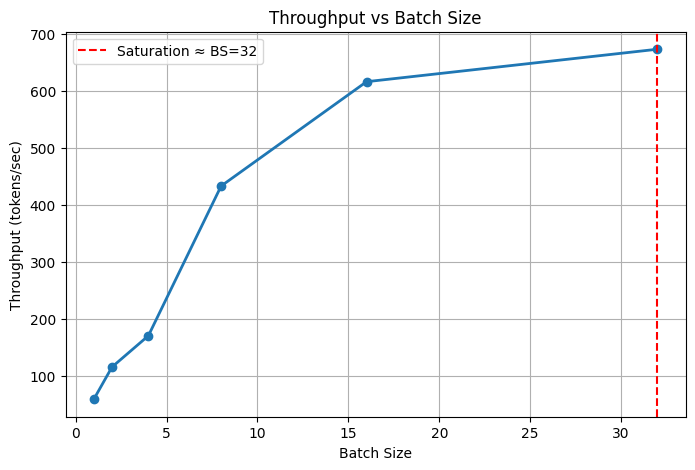

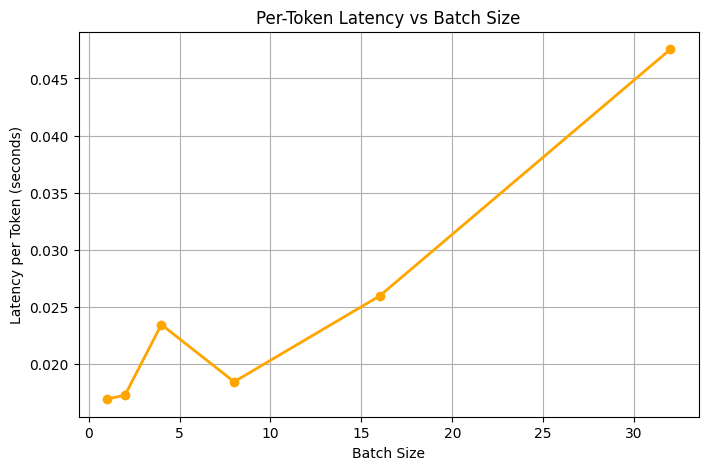

In [ ]:
import time
import torch
import pandas as pd
import matplotlib.pyplot as plt
from transformers import AutoTokenizer, AutoModelForCausalLM

# --------------------------------------------------
# Configuration
# --------------------------------------------------
MODEL_NAME = "gpt2-medium"  # replace with your model
SEQ_LEN = 512
NEW_TOKENS = 128
BATCH_SIZES = [1, 2, 4, 8, 16,32]
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# --------------------------------------------------
# Load model
# --------------------------------------------------
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token
model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    torch_dtype=torch.float16 if DEVICE == "cuda" else torch.float32
).to(DEVICE)

model.eval()

# --------------------------------------------------
# Create fixed 512-token prompt
# --------------------------------------------------
text = "The quick brown fox jumps over the lazy dog. "

tokens = tokenizer(text, return_tensors="pt")["input_ids"][0]

repeat_factor = (SEQ_LEN // len(tokens)) + 1
prompt_ids = tokens.repeat(repeat_factor)[:SEQ_LEN]

results = []

# --------------------------------------------------
# Benchmark
# --------------------------------------------------
for batch_size in BATCH_SIZES:

    input_ids = prompt_ids.unsqueeze(0).repeat(batch_size, 1).to(DEVICE)
    attention_mask = torch.ones_like(input_ids)

    # Warmup
    with torch.no_grad():
        _ = model.generate(
            input_ids,
            attention_mask=attention_mask,
            max_new_tokens=8,
            do_sample=False
        )

    torch.cuda.synchronize() if DEVICE == "cuda" else None

    start = time.perf_counter()

    with torch.no_grad():
        _ = model.generate(
            input_ids,
            attention_mask=attention_mask,
            max_new_tokens=NEW_TOKENS,
            do_sample=False
        )

    torch.cuda.synchronize() if DEVICE == "cuda" else None

    end = time.perf_counter()

    elapsed = end - start

    total_generated_tokens = batch_size * NEW_TOKENS

    throughput = total_generated_tokens / elapsed

    latency_per_token = elapsed / NEW_TOKENS

    results.append({
        "Batch Size": batch_size,
        "Time (s)": elapsed,
        "Throughput (tok/s)": throughput,
        "Latency per Token (s)": latency_per_token
    })

# --------------------------------------------------
# Results table
# --------------------------------------------------
df = pd.DataFrame(results)

print("\nBenchmark Results")
print(df.to_string(index=False))

# --------------------------------------------------
# Saturation point
# --------------------------------------------------
throughputs = df["Throughput (tok/s)"].values

saturation_batch = None

for i in range(1, len(throughputs)):
    improvement = (
        (throughputs[i] - throughputs[i - 1])
        / throughputs[i - 1]
    )

    if improvement < 0.10:  # <10% gain
        saturation_batch = BATCH_SIZES[i]
        break

print(f"\nEstimated Saturation Batch Size: {saturation_batch}")

# --------------------------------------------------
# Plot Throughput
# --------------------------------------------------
plt.figure(figsize=(8, 5))
plt.plot(
    df["Batch Size"],
    df["Throughput (tok/s)"],
    marker="o",
    linewidth=2
)

if saturation_batch is not None:
    sat_tp = df.loc[
        df["Batch Size"] == saturation_batch,
        "Throughput (tok/s)"
    ].values[0]

    plt.axvline(
        saturation_batch,
        linestyle="--",
        color="red",
        label=f"Saturation ≈ BS={saturation_batch}"
    )

plt.xlabel("Batch Size")
plt.ylabel("Throughput (tokens/sec)")
plt.title("Throughput vs Batch Size")
plt.grid(True)
plt.legend()
plt.show()

# --------------------------------------------------
# Plot Latency
# --------------------------------------------------
plt.figure(figsize=(8, 5))
plt.plot(
    df["Batch Size"],
    df["Latency per Token (s)"],
    marker="o",
    linewidth=2,
    color="orange"
)

plt.xlabel("Batch Size")
plt.ylabel("Latency per Token (seconds)")
plt.title("Per-Token Latency vs Batch Size")
plt.grid(True)
plt.show()


config.json:   0%|          | 0.00/666 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/3.25G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/436 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

[transformers] Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
[transformers] Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
[transformers] Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
[transformers] Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
[transformers] Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
[transformers] Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
[transformers] Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
[transformers] Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
[transformers] Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
[transformers] Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
[transformers] Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
[transformers] Setting `pad_token_id` to `e


Benchmark Results
 Batch Size  Time (s)  Throughput (tok/s)  Latency per Token (s)
          1  3.219375           39.759268               0.025151
          2  3.340058           76.645375               0.026094
          4  3.764320          136.013946               0.029409
          8  4.050128          252.831485               0.031642
         16  6.882551          297.564071               0.053770
         32 13.452240          304.484607               0.105096

Estimated Saturation Batch Size: 32


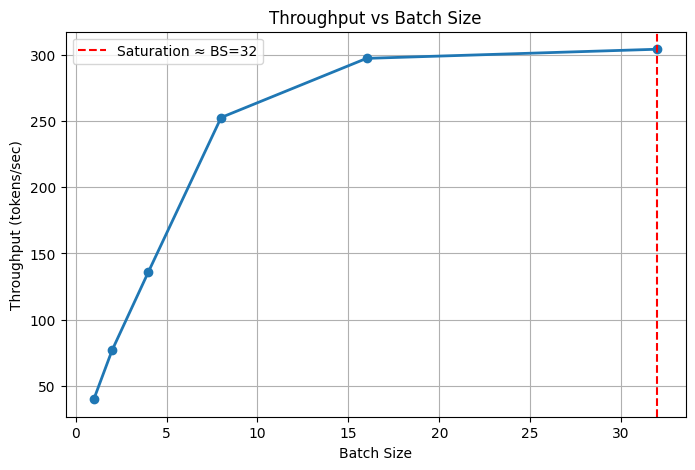

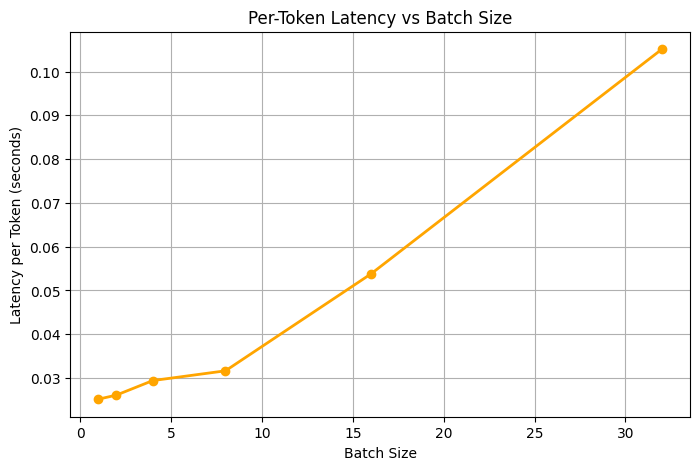

In [ ]:
import time
import torch
import pandas as pd
import matplotlib.pyplot as plt
from transformers import AutoTokenizer, AutoModelForCausalLM

# --------------------------------------------------
# Configuration
# --------------------------------------------------
MODEL_NAME = "gpt2-large"  # replace with your model
SEQ_LEN = 512
NEW_TOKENS = 128
BATCH_SIZES = [1, 2, 4, 8, 16,32]
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# --------------------------------------------------
# Load model
# --------------------------------------------------
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token
model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    torch_dtype=torch.float16 if DEVICE == "cuda" else torch.float32
).to(DEVICE)

model.eval()

# --------------------------------------------------
# Create fixed 512-token prompt
# --------------------------------------------------
text = "The quick brown fox jumps over the lazy dog. "

tokens = tokenizer(text, return_tensors="pt")["input_ids"][0]

repeat_factor = (SEQ_LEN // len(tokens)) + 1
prompt_ids = tokens.repeat(repeat_factor)[:SEQ_LEN]

results = []

# --------------------------------------------------
# Benchmark
# --------------------------------------------------
for batch_size in BATCH_SIZES:

    input_ids = prompt_ids.unsqueeze(0).repeat(batch_size, 1).to(DEVICE)
    attention_mask = torch.ones_like(input_ids)

    # Warmup
    with torch.no_grad():
        _ = model.generate(
            input_ids,
            attention_mask=attention_mask,
            max_new_tokens=8,
            do_sample=False
        )

    torch.cuda.synchronize() if DEVICE == "cuda" else None

    start = time.perf_counter()

    with torch.no_grad():
        _ = model.generate(
            input_ids,
            attention_mask=attention_mask,
            max_new_tokens=NEW_TOKENS,
            do_sample=False
        )

    torch.cuda.synchronize() if DEVICE == "cuda" else None

    end = time.perf_counter()

    elapsed = end - start

    total_generated_tokens = batch_size * NEW_TOKENS

    throughput = total_generated_tokens / elapsed

    latency_per_token = elapsed / NEW_TOKENS

    results.append({
        "Batch Size": batch_size,
        "Time (s)": elapsed,
        "Throughput (tok/s)": throughput,
        "Latency per Token (s)": latency_per_token
    })

# --------------------------------------------------
# Results table
# --------------------------------------------------
df = pd.DataFrame(results)

print("\nBenchmark Results")
print(df.to_string(index=False))

# --------------------------------------------------
# Saturation point
# --------------------------------------------------
throughputs = df["Throughput (tok/s)"].values

saturation_batch = None

for i in range(1, len(throughputs)):
    improvement = (
        (throughputs[i] - throughputs[i - 1])
        / throughputs[i - 1]
    )

    if improvement < 0.10:  # <10% gain
        saturation_batch = BATCH_SIZES[i]
        break

print(f"\nEstimated Saturation Batch Size: {saturation_batch}")

# --------------------------------------------------
# Plot Throughput
# --------------------------------------------------
plt.figure(figsize=(8, 5))
plt.plot(
    df["Batch Size"],
    df["Throughput (tok/s)"],
    marker="o",
    linewidth=2
)

if saturation_batch is not None:
    sat_tp = df.loc[
        df["Batch Size"] == saturation_batch,
        "Throughput (tok/s)"
    ].values[0]

    plt.axvline(
        saturation_batch,
        linestyle="--",
        color="red",
        label=f"Saturation ≈ BS={saturation_batch}"
    )

plt.xlabel("Batch Size")
plt.ylabel("Throughput (tokens/sec)")
plt.title("Throughput vs Batch Size")
plt.grid(True)
plt.legend()
plt.show()

# --------------------------------------------------
# Plot Latency
# --------------------------------------------------
plt.figure(figsize=(8, 5))
plt.plot(
    df["Batch Size"],
    df["Latency per Token (s)"],
    marker="o",
    linewidth=2,
    color="orange"
)

plt.xlabel("Batch Size")
plt.ylabel("Latency per Token (seconds)")
plt.title("Per-Token Latency vs Batch Size")
plt.grid(True)
plt.show()


Loading weights:   0%|          | 0/436 [00:00<?, ?it/s]

[transformers] Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
[transformers] Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
[transformers] Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
[transformers] Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
[transformers] Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
[transformers] Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
[transformers] Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
[transformers] Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
[transformers] Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
[transformers] Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
[transformers] Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
[transformers] Setting `pad_token_id` to `e


Benchmark Results
 Batch Size  Time (s)  Throughput (tok/s)  Latency per Token (s)
          1  3.883868           32.956834               0.030343
          2  3.368734           75.992936               0.026318
          4  3.571085          143.373799               0.027899
          8  4.674812          219.046222               0.036522
         16  7.728676          264.987183               0.060380
         32 14.630745          279.958408               0.114303

Estimated Saturation Batch Size: 32


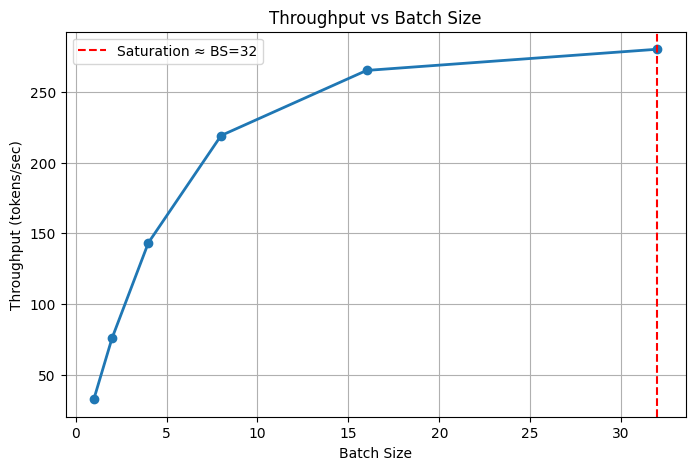

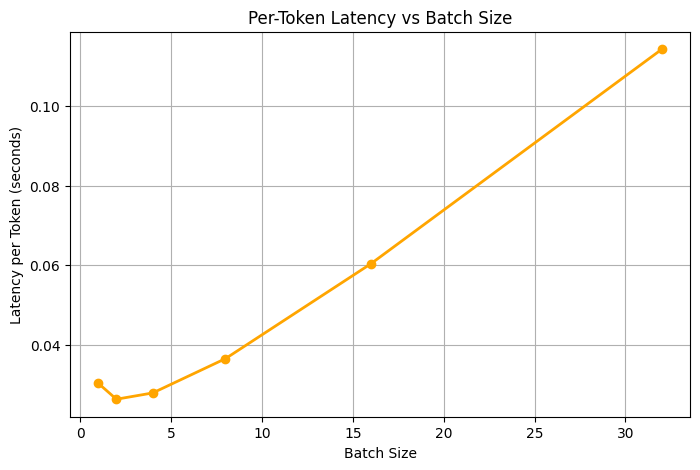

In [ ]:
import time
import torch
import pandas as pd
import matplotlib.pyplot as plt
from transformers import AutoTokenizer, AutoModelForCausalLM

# --------------------------------------------------
# Configuration
# --------------------------------------------------
MODEL_NAME = "gpt2-large"  # replace with your model
SEQ_LEN = 512
NEW_TOKENS = 128
BATCH_SIZES = [1, 2, 4, 8, 16,32]
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# --------------------------------------------------
# Load model
# --------------------------------------------------
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token
model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    torch_dtype=torch.float16 if DEVICE == "cuda" else torch.float32
).to(DEVICE)

model.eval()

# --------------------------------------------------
# Create fixed 512-token prompt
# --------------------------------------------------
text = "The quick brown fox jumps over the lazy dog. "

tokens = tokenizer(text, return_tensors="pt")["input_ids"][0]

repeat_factor = (SEQ_LEN // len(tokens)) + 1
prompt_ids = tokens.repeat(repeat_factor)[:SEQ_LEN]

results = []

# --------------------------------------------------
# Benchmark
# --------------------------------------------------
for batch_size in BATCH_SIZES:

    input_ids = prompt_ids.unsqueeze(0).repeat(batch_size, 1).to(DEVICE)
    attention_mask = torch.ones_like(input_ids)

    # Warmup
    with torch.no_grad():
        _ = model.generate(
            input_ids,
            attention_mask=attention_mask,
            max_new_tokens=8,
            do_sample=False
        )

    torch.cuda.synchronize() if DEVICE == "cuda" else None

    start = time.perf_counter()

    with torch.no_grad():
        _ = model.generate(
            input_ids,
            attention_mask=attention_mask,
            max_new_tokens=NEW_TOKENS,
            do_sample=False
        )

    torch.cuda.synchronize() if DEVICE == "cuda" else None

    end = time.perf_counter()

    elapsed = end - start

    total_generated_tokens = batch_size * NEW_TOKENS

    throughput = total_generated_tokens / elapsed

    latency_per_token = elapsed / NEW_TOKENS

    results.append({
        "Batch Size": batch_size,
        "Time (s)": elapsed,
        "Throughput (tok/s)": throughput,
        "Latency per Token (s)": latency_per_token
    })

# --------------------------------------------------
# Results table
# --------------------------------------------------
df = pd.DataFrame(results)

print("\nBenchmark Results")
print(df.to_string(index=False))

# --------------------------------------------------
# Saturation point
# --------------------------------------------------
throughputs = df["Throughput (tok/s)"].values

saturation_batch = None

for i in range(1, len(throughputs)):
    improvement = (
        (throughputs[i] - throughputs[i - 1])
        / throughputs[i - 1]
    )

    if improvement < 0.10:  # <10% gain
        saturation_batch = BATCH_SIZES[i]
        break

print(f"\nEstimated Saturation Batch Size: {saturation_batch}")

# --------------------------------------------------
# Plot Throughput
# --------------------------------------------------
plt.figure(figsize=(8, 5))
plt.plot(
    df["Batch Size"],
    df["Throughput (tok/s)"],
    marker="o",
    linewidth=2
)

if saturation_batch is not None:
    sat_tp = df.loc[
        df["Batch Size"] == saturation_batch,
        "Throughput (tok/s)"
    ].values[0]

    plt.axvline(
        saturation_batch,
        linestyle="--",
        color="red",
        label=f"Saturation ≈ BS={saturation_batch}"
    )

plt.xlabel("Batch Size")
plt.ylabel("Throughput (tokens/sec)")
plt.title("Throughput vs Batch Size")
plt.grid(True)
plt.legend()
plt.show()

# --------------------------------------------------
# Plot Latency
# --------------------------------------------------
plt.figure(figsize=(8, 5))
plt.plot(
    df["Batch Size"],
    df["Latency per Token (s)"],
    marker="o",
    linewidth=2,
    color="orange"
)

plt.xlabel("Batch Size")
plt.ylabel("Latency per Token (seconds)")
plt.title("Per-Token Latency vs Batch Size")
plt.grid(True)
plt.show()


The latency/throughput trade-off in Large Language Models (LLMs) represents the fundamental engineering struggle between generating rapid responses for a single user (low latency) and maximizing the number of simultaneous requests the hardware can handle (high throughput).

The model reads your entire input at once to generate the first output token. This phase is highly mathematical (compute-bound) and utilizes the GPU's computing cores completely, which causes higher initial latency.
